In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

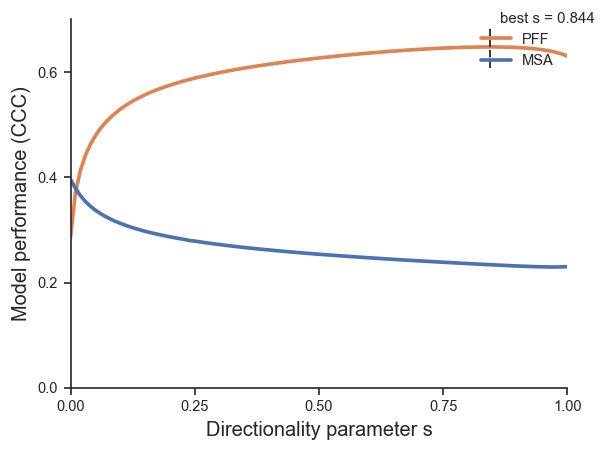

In [2]:

# -------------------------
# Style
# -------------------------
sns.set_theme(style="white", context="paper")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.linewidth": 1.0,
})


# -------------------------
# Colors
# -------------------------
COLOR_MSA = "#4C72B0"
COLOR_PFF = "#DD8452"


# -------------------------
# Project paths
# -------------------------
# The Jupyter Notebook working directory should be:
# Code/Figures Python
project_dir = Path.cwd()

data_dir = project_dir / "Data"
results_dir = project_dir / "Results"


# -------------------------
# Input
# -------------------------
file = data_dir / "MSA_PFF_Test_Global_Directionality_s.xlsx"

df_msa = pd.read_excel(
    file,
    sheet_name="MSA",
    header=0
)

df_pff = pd.read_excel(
    file,
    sheet_name="PFF",
    header=0
)


# -------------------------
# Prepare data
# -------------------------
# First column = directionality parameter s
# Second column = model performance CCC
df_msa = df_msa.iloc[:, :2].copy()
df_pff = df_pff.iloc[:, :2].copy()

df_msa.columns = ["s", "CCC"]
df_pff.columns = ["s", "CCC"]

# Remove missing values and sort by directionality parameter.
df_msa = (
    df_msa
    .dropna(subset=["s", "CCC"])
    .sort_values("s")
)

df_pff = (
    df_pff
    .dropna(subset=["s", "CCC"])
    .sort_values("s")
)


# -------------------------
# Output
# -------------------------
out_dir = (
    results_dir
    / "MSA_PFF_Test_Global_Directionality_s"
)

out_dir.mkdir(parents=True, exist_ok=True)


# Common x-axis ticks
xticks = [0, 0.25, 0.5, 0.75, 1.0]


# Best-fitting PFF directionality parameter
best_s_pff = 0.84433716


# -------------------------
# Plot CCC versus directionality
# -------------------------
fig, ax = plt.subplots(figsize=(5.2, 3.9))

# MSA and PFF curves
ax.plot(
    df_pff["s"],
    df_pff["CCC"],
    color=COLOR_PFF,
    linewidth=2.2,
    label="PFF"
)

ax.plot(
    df_msa["s"],
    df_msa["CCC"],
    color=COLOR_MSA,
    linewidth=2.2,
    label="MSA"
)


# -------------------------
# Axis settings
# -------------------------
ax.set_xlim(0, 1)
ax.set_xticks(xticks)

# Common y-axis range for both curves
ax.set_ylim(0, 0.7)
ax.set_yticks([0, 0.2, 0.4, 0.6])

ax.set_xlabel("Directionality parameter s")
ax.set_ylabel("Model performance (CCC)")


# -------------------------
# Short vertical marker near PFF optimum
# -------------------------
# Find the tested s value closest to the fitted best_s_pff.
idx = (
    df_pff["s"] - best_s_pff
).abs().idxmin()

y_best = float(
    df_pff.loc[idx, "CCC"]
)

# Draw only a short vertical segment around the corresponding CCC.
seg = 0.04

y0 = max(
    ax.get_ylim()[0],
    y_best - seg
)

y1 = min(
    ax.get_ylim()[1],
    y_best + seg
)

ax.vlines(
    best_s_pff,
    y0,
    y1,
    colors="k",
    linestyles="--",
    linewidth=1.2,
    alpha=0.85
)

ax.text(
    best_s_pff + 0.02,
    y1,
    f"best s = {best_s_pff:.3f}",
    ha="left",
    va="bottom",
    fontsize=9
)


# -------------------------
# Legend and axis style
# -------------------------
ax.legend(
    frameon=False,
    loc="upper right"
)

sns.despine(
    ax=ax,
    top=True,
    right=True,
    left=False,
    bottom=False
)

ax.tick_params(
    axis="both",
    which="major",
    bottom=True,
    left=True,
    direction="out",
    length=4,
    width=1.0
)

plt.tight_layout()

In [3]:
# -------------------------
# Save CCC-versus-s figure
# -------------------------
fig.savefig(
    out_dir / "PFF_MSA_CCC_vs_s_overlay.pdf",
    bbox_inches="tight"
)

fig.savefig(
    out_dir / "PFF_MSA_CCC_vs_s_overlay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

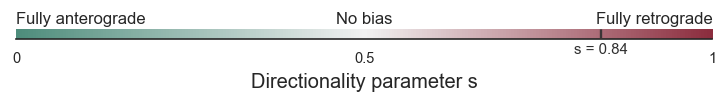

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# -------------------------
# Directionality colormap
# -------------------------
cmap = LinearSegmentedColormap.from_list(
    "directionality",
    [
        "#4E8D7C",  # anterograde
        "#F2F2F2",  # no bias
        "#8C2D3E"   # retrograde
    ]
)


# Best-fitting PFF directionality parameter
best_s = 0.84


# -------------------------
# Draw directionality schematic
# -------------------------
fig, ax = plt.subplots(figsize=(6.2, 1.2))

# Continuous directionality gradient
grad = np.linspace(0, 1, 600)[None, :]

ax.imshow(
    grad,
    aspect="auto",
    cmap=cmap,
    extent=[0, 1, 0, 1]
)


# -------------------------
# Mark fitted directionality
# -------------------------
ax.vlines(
    best_s,
    ymin=0.05,
    ymax=0.95,
    colors="#2F2F2F",
    linestyles="--",
    linewidth=1.4,
    alpha=0.9
)

ax.text(
    best_s,
    -0.35,
    "s = 0.84",
    ha="center",
    va="top",
    fontsize=9,
    color="#2F2F2F"
)


# -------------------------
# Axis settings
# -------------------------
ax.set_yticks([])

ax.set_xlim(0, 1)

ax.set_xticks([
    0,
    0.5,
    1
])

ax.set_xticklabels([
    "0",
    "0.5",
    "1"
])

ax.tick_params(
    axis="x",
    direction="out",
    length=4,
    width=1.0
)


# -------------------------
# Directionality labels
# -------------------------
ax.text(
    0,
    1.25,
    "Fully anterograde",
    ha="left",
    va="bottom",
    fontsize=10
)

ax.text(
    0.5,
    1.25,
    "No bias",
    ha="center",
    va="bottom",
    fontsize=10
)

ax.text(
    1,
    1.25,
    "Fully retrograde",
    ha="right",
    va="bottom",
    fontsize=10
)

ax.set_xlabel(
    "Directionality parameter s"
)


# -------------------------
# Clean axis appearance
# -------------------------
for sp in [
    "top",
    "right",
    "left"
]:
    ax.spines[sp].set_visible(False)

plt.tight_layout()


# -------------------------
# Save directionality schematic
# -------------------------
fig.savefig(
    out_dir / "s_schematic.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    out_dir / "s_schematic.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close(fig)